Device: cuda

=== Deep SAD TRAIN SPLIT ===
Labeled Xl size           : 809
  + labeled normals (+1)  : 800
  + labeled anomalies (-1): 9

Unlabeled Xu size         : 31341
  + true normals          : 21000
  + true anomalies        : 10341

Real data:
  + real normals          : 54
  + real anomalies        : 28

=== Few-shot REAL split ===
Fixed real normal pool: 10
Selected real reference: 1
Real test size       : 72
Real test normals    : 44
Real test anomalies  : 28

==================== FEATURE GROUPS ====================
Categorical: []
Numeric: ['Length', 'stNum', 'sqNum', 'heartbeat', 'dif_stNum', 'dif_sqNum', 'Circuit breaker Open/Close Status', 'I-high VT', 'I-high VT- Tran', 'I-low VT- Tran', 'I-amongst-feeders']

X_ref_fewshot shape: (801, 11)

>>> PHASE 1: Model selection by ORIGINAL Deep SAD validation score
>>> N_REAL_REF = 1

[1/1] Try eta=1.0 | ae_epochs=50 | lr=0.0001->1e-05


/tmp/ipykernel_42574/2983189130.py:193: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_object_dtype(Xu_df[c]) or pd.api.types.is_categorical_dtype(Xu_df[c])


  -> ORIGINAL VAL F1_binary(anomaly) = 0.87719 at q=0.9990, thr=0.449315

=== Grid search results: ORIGINAL Deep SAD score ===
 1. Original_F1_VAL=0.87719 | eta=1.0 | ae_epochs=50 | lr=0.0001->1e-05 | q*=0.9990 | thr*=0.449315

>>> BEST MODEL by ORIGINAL Deep SAD validation score:
Best ORIGINAL VAL F1: 0.87719
Best cfg: {'eta': 1.0, 'ae_epochs': 50, 'lr_search': 0.0001, 'lr_finetune': 1e-05}
Best original q: 0.9990
Best original threshold: 0.449315

Saved best model:
DeepSAD_best_encoder_selected_by_original_score.pt
DeepSAD_best_center_selected_by_original_score.pt

>>> PHASE 2: Threshold selection by FEW-SHOT Local Density score
Best LD VAL F1: 0.06061
Best LD q: 0.9990
Best LD threshold: 1.007367

>>> FINAL TEST: Deep SAD + Few-shot Local Density Score
>>> Reference = labeled simulation normal (800) + real normal few-shot (1)
>>> Test = remaining real normal (44) + all real anomaly (28)

=== TEST RESULTS: BEST Deep SAD MODEL + FEW-SHOT LD SCORE ===
N_REAL_REF: 1
Best ORIGINAL VAL F1

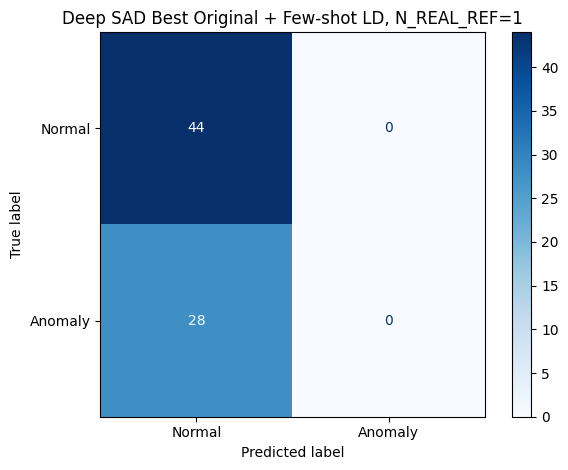

Saved: DeepSAD_best_original_confusion_matrix_fewshot_LD_ref1.png
Saved: DeepSAD_best_original_test_scores_fewshot_LD_ref1.csv
Saved: DeepSAD_real_normal_reference_fewshot.csv
Saved: DeepSAD_real_test_after_fewshot_split.csv
Saved: DeepSAD_best_encoder_selected_by_original_score.pt
Saved: DeepSAD_best_center_selected_by_original_score.pt

Training time: 2 min 11.85 s
Testing time : 0 min 00.03 s
Total time   : 2 min 11.88 s


In [2]:
# ============================================================
# Deep SAD + Few-shot Real Normal Reference
# Local Density-Based Anomaly Score Normalization
#
# Train: label_pool.csv + unlabeled_pool.csv
# Validation: val_labeled_40.csv
# Few-shot reference: N real normal samples from real_data.csv
# Test: remaining real normal + all real anomaly
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional, Dict
from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    classification_report,
    ConfusionMatrixDisplay,
)
from inspect import signature
import matplotlib.pyplot as plt
from copy import deepcopy
import random
import time

t0 = time.perf_counter()

# ============================================================
# 0) Reproducibility
# ============================================================
SEED = 42
N_REAL_REF = 1


np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ============================================================
# 1) Load CSVs
# ============================================================
label_df     = pd.read_csv("label_pool.csv")
unlabeled_df = pd.read_csv("unlabeled_pool.csv")
val_df       = pd.read_csv("val_labeled_40.csv")
real_df      = pd.read_csv("real_data.csv")

for df in (label_df, unlabeled_df, val_df, real_df):
    for col in ["Unnamed: 0", "Source", "goID"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

FEATURES = [c for c in label_df.columns if c != "Label"]

Xl_df  = label_df[FEATURES].copy()
yl_raw = label_df["Label"].to_numpy().astype(int)
yl_pm  = np.where(yl_raw == 0, +1, -1)

Xu_df = unlabeled_df[FEATURES].copy()
yu_true = unlabeled_df["Label"].to_numpy().astype(int) if "Label" in unlabeled_df.columns else None

X_val_df = val_df[FEATURES].copy()
y_val = val_df["Label"].to_numpy().astype(np.int64)

X_real_df = real_df[FEATURES].copy()
y_real = real_df["Label"].to_numpy().astype(np.int64)

print("\n=== Deep SAD TRAIN SPLIT ===")
print(f"Labeled Xl size           : {len(Xl_df)}")
print(f"  + labeled normals (+1)  : {(yl_pm > 0).sum()}")
print(f"  + labeled anomalies (-1): {(yl_pm < 0).sum()}")

print(f"\nUnlabeled Xu size         : {len(Xu_df)}")
if yu_true is not None:
    print(f"  + true normals          : {(yu_true == 0).sum()}")
    print(f"  + true anomalies        : {(yu_true == 1).sum()}")

print("\nReal data:")
print(f"  + real normals          : {(y_real == 0).sum()}")
print(f"  + real anomalies        : {(y_real == 1).sum()}")

# ============================================================
# 2) Few-shot split real data
#    Step 1: reserve 10 fixed real normal samples
#    Step 2: choose N_REAL_REF from those 10 samples
#    Step 3: remaining real data is used for test
# ============================================================

N_REAL_POOL = 10
N_REAL_REF = 1

if N_REAL_REF not in [1, 2, 5, 10]:
    raise ValueError("N_REAL_REF must be one of [1, 2, 5, 10].")

idx_real_norm = np.flatnonzero(y_real == 0)
idx_real_anom = np.flatnonzero(y_real == 1)

if len(idx_real_norm) < N_REAL_POOL:
    raise ValueError(
        f"real_data.csv has only {len(idx_real_norm)} normal samples, "
        f"but N_REAL_POOL={N_REAL_POOL} is required."
    )

# Step 1: reserve fixed 10 real normal samples
np.random.seed(SEED)

real_pool_10_idx = np.random.choice(
    idx_real_norm,
    size=N_REAL_POOL,
    replace=False
)

# Step 2: choose N_REAL_REF samples from fixed 10-sample pool
real_ref_idx = real_pool_10_idx[:N_REAL_REF]

# Step 3: real test = all real data except the fixed 10 normal pool
real_test_norm_idx = np.array([
    i for i in idx_real_norm
    if i not in set(real_pool_10_idx)
])

real_test_anom_idx = idx_real_anom.copy()

real_test_idx = np.concatenate([
    real_test_norm_idx,
    real_test_anom_idx
])

X_real_pool_10_df = X_real_df.iloc[real_pool_10_idx].copy()
y_real_pool_10 = y_real[real_pool_10_idx]

X_real_ref_df = X_real_df.iloc[real_ref_idx].copy()
y_real_ref = y_real[real_ref_idx]

X_test_df = X_real_df.iloc[real_test_idx].copy()
y_test = y_real[real_test_idx]

print("\n=== Few-shot REAL split ===")
print("Fixed real normal pool:", len(y_real_pool_10))
print("Selected real reference:", len(y_real_ref))
print("Real test size       :", len(y_test))
print("Real test normals    :", (y_test == 0).sum())
print("Real test anomalies  :", (y_test == 1).sum())

pd.concat(
    [X_real_pool_10_df.reset_index(drop=True), pd.Series(y_real_pool_10, name="Label")],
    axis=1
).to_csv(
    "DeepSAD_real_normal_pool_10_fixed.csv",
    index=False
)

pd.concat(
    [X_real_ref_df.reset_index(drop=True), pd.Series(y_real_ref, name="Label")],
    axis=1
).to_csv(
    f"DeepSAD_real_normal_reference_from_pool10_ref{N_REAL_REF}.csv",
    index=False
)

pd.concat(
    [X_test_df.reset_index(drop=True), pd.Series(y_test, name="Label")],
    axis=1
).to_csv(
    "DeepSAD_real_test_excluding_pool10.csv",
    index=False
)

# ============================================================
# 3) Preprocess
# Fit ONLY on training data: Xu + Xl
# ============================================================
obj_cols = [
    c for c in Xu_df.columns
    if pd.api.types.is_object_dtype(Xu_df[c]) or pd.api.types.is_categorical_dtype(Xu_df[c])
]
num_cols = [c for c in Xu_df.columns if c not in obj_cols]

print("\n==================== FEATURE GROUPS ====================")
print("Categorical:", obj_cols)
print("Numeric:", num_cols)
print("========================================================\n")

if "sparse_output" in signature(OneHotEncoder).parameters:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("cat", ohe, obj_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

pre.fit(pd.concat([Xu_df, Xl_df], axis=0))

def tf(df: pd.DataFrame) -> np.ndarray:
    return pre.transform(df).astype(np.float32)

Xu = tf(Xu_df)
Xl = tf(Xl_df)
Xv = tf(X_val_df)

X_real_ref = tf(X_real_ref_df)
Xt = tf(X_test_df)

Xu_fixed = Xu.copy()
Xl_fixed = Xl.copy()
yl_fixed = yl_pm.copy()

# Reference = labeled simulation normal + few-shot real normal
Xl_norm = Xl_fixed[yl_fixed > 0]
X_ref_fewshot = np.concatenate([Xl_norm, X_real_ref], axis=0).astype(np.float32)

print("X_ref_fewshot shape:", X_ref_fewshot.shape)

# ============================================================
# 4) Deep SAD model
# ============================================================
@dataclass
class DeepSADConfig:
    hid: int = 16
    zdim: int = 4
    batch_size: int = 128
    weight_decay: float = 1e-5
    lr_search: float = 1e-4
    lr_finetune: float = 1e-5
    epochs_search: int = 30
    epochs_finetune: int = 180
    eta: float = 1.0
    device: str = device
    ae_epochs: int = 50
    ae_lr: float = 1e-3
    dropout: float = 0.0

class Encoder(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64, z: int = 8, p_drop: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hid, z),
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, out_dim: int, hid: int = 64, z: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, out_dim),
        )

    def forward(self, z):
        return self.net(z)

class Autoencoder(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64, z: int = 8):
        super().__init__()
        self.encoder = Encoder(in_dim, hid=hid, z=z)
        self.decoder = Decoder(in_dim, hid=hid, z=z)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

class DeepSAD:
    def __init__(self, in_dim: int, cfg: DeepSADConfig):
        self.cfg = cfg
        self.encoder = Encoder(in_dim, hid=cfg.hid, z=cfg.zdim).to(cfg.device)
        self.c = torch.zeros(cfg.zdim, device=cfg.device)

    def set_center(self, c_vec: torch.Tensor):
        self.c = c_vec.detach().to(self.cfg.device)

    @torch.no_grad()
    def compute_center(self, loader_all_but_labeled_anom: DataLoader):
        self.encoder.eval()
        s = torch.zeros_like(self.c)
        n = 0

        for x in loader_all_but_labeled_anom:
            x = x[0] if isinstance(x, (tuple, list)) else x
            x = x.to(self.cfg.device)
            z = self.encoder(x)
            s += z.sum(0)
            n += z.size(0)

        c = s / max(n, 1)
        c[c.abs() < 1e-6] = 1e-6
        self.set_center(c)
        return c

    def anomaly_score(self, X: torch.Tensor):
        self.encoder.eval()
        with torch.no_grad():
            z = self.encoder(X.to(self.cfg.device))
            return torch.linalg.norm(z - self.c, dim=1)

def _xavier_uniform_linear(m: nn.Module):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

def _mk_loader(X: np.ndarray, y: Optional[np.ndarray], bs: int, sh: bool = True) -> DataLoader:
    X_t = torch.from_numpy(X).float()

    if y is None:
        ds = TensorDataset(X_t)
    else:
        ds = TensorDataset(X_t, torch.from_numpy(y).float())

    return DataLoader(ds, batch_size=bs, shuffle=sh, drop_last=False)

def pretrain_ae(X_all: np.ndarray, in_dim: int, cfg: DeepSADConfig) -> Autoencoder:
    ae = Autoencoder(in_dim, hid=cfg.hid, z=cfg.zdim).to(cfg.device)
    ae.apply(_xavier_uniform_linear)

    opt = torch.optim.Adam(
        ae.parameters(),
        lr=cfg.ae_lr,
        weight_decay=cfg.weight_decay,
    )

    loader = _mk_loader(X_all, None, cfg.batch_size, True)

    ae.train()
    for _ in range(cfg.ae_epochs):
        for (xb,) in loader:
            xb = xb.to(cfg.device)
            xh, _ = ae(xb)

            loss = F.mse_loss(xh, xb)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

    return ae

def _deep_sad_loss(zu, zl, yl, c, eta, eps=1e-8):
    du2 = ((zu - c) ** 2).sum(1)
    loss_u = du2.mean() if zu.numel() else torch.tensor(0.0, device=c.device)

    if zl.numel():
        dl2 = ((zl - c) ** 2).sum(1)
        y = yl.view(-1)

        lp = dl2[y > 0].mean() if (y > 0).any() else torch.tensor(0.0, device=c.device)
        ln = (1.0 / (dl2[y < 0] + eps)).mean() if (y < 0).any() else torch.tensor(0.0, device=c.device)

        return loss_u + eta * (lp + ln)

    return loss_u

def train_deepsad(Xu: np.ndarray, Xl: np.ndarray, yl: np.ndarray, cfg: DeepSADConfig) -> Dict:
    in_dim = Xu.shape[1]

    ae = pretrain_ae(np.concatenate([Xu, Xl], axis=0), in_dim, cfg)

    model = DeepSAD(in_dim, cfg)
    model.encoder.load_state_dict(ae.encoder.state_dict())

    ld_u = _mk_loader(Xu, None, cfg.batch_size, True)
    ld_l = _mk_loader(Xl, yl, cfg.batch_size, True)

    X_lab_norm = Xl[yl > 0]

    ld_center = _mk_loader(
        np.concatenate([Xu, X_lab_norm], axis=0),
        None,
        cfg.batch_size,
        False,
    )

    _ = model.compute_center(ld_center)

    opt = torch.optim.Adam(
        model.encoder.parameters(),
        lr=cfg.lr_search,
        weight_decay=cfg.weight_decay,
    )

    def phase(epochs, lr):
        for g in opt.param_groups:
            g["lr"] = lr

        for _ in range(epochs):
            model.encoder.train()

            it_u = iter(ld_u)
            it_l = iter(ld_l)

            steps = max(len(ld_u), len(ld_l))

            for _ in range(steps):
                try:
                    xb_u = next(it_u)[0].to(cfg.device)
                except StopIteration:
                    it_u = iter(ld_u)
                    xb_u = next(it_u)[0].to(cfg.device)

                try:
                    xb_l, yb_l = next(it_l)
                    xb_l = xb_l.to(cfg.device)
                    yb_l = yb_l.to(cfg.device)
                except StopIteration:
                    it_l = iter(ld_l)
                    xb_l, yb_l = next(it_l)
                    xb_l = xb_l.to(cfg.device)
                    yb_l = yb_l.to(cfg.device)

                zu = model.encoder(xb_u)
                zl = model.encoder(xb_l)

                loss = _deep_sad_loss(zu, zl, yb_l, model.c, cfg.eta)

                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

    phase(cfg.epochs_search, cfg.lr_search)
    phase(cfg.epochs_finetune, cfg.lr_finetune)

    def score_fn(X: np.ndarray, bs: int = 1024) -> np.ndarray:
        loader = _mk_loader(X, None, bs, False)
        ss = []

        model.encoder.eval()
        with torch.no_grad():
            for (xb,) in loader:
                d = model.anomaly_score(xb)
                ss.append(d.cpu().numpy())

        return np.concatenate(ss, axis=0)

    return {
        "encoder": model.encoder,
        "center": model.c.detach().clone(),
        "config": cfg,
        "score_fn": score_fn,
    }

# ============================================================
# 5) Local Density-Based Score using Deep SAD encoder
# ============================================================
def _encode_numpy(encoder: nn.Module, X: np.ndarray, bs: int = 1024) -> np.ndarray:
    encoder.eval()
    loader = _mk_loader(X, None, bs, False)
    zs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            z = encoder(xb)
            zs.append(z.cpu().numpy())

    return np.concatenate(zs, axis=0)

def local_density_scores_deepsad(
    encoder: nn.Module,
    X_ref: np.ndarray,
    X_split: np.ndarray,
    bs: int = 1024,
    eps: float = 1e-8,
) -> np.ndarray:
    Z_ref = _encode_numpy(encoder, X_ref, bs=bs)
    Z_split = _encode_numpy(encoder, X_split, bs=bs)

    Z_ref_t = torch.from_numpy(Z_ref).float().to(device)
    Z_split_t = torch.from_numpy(Z_split).float().to(device)

    with torch.no_grad():
        D_ref = torch.cdist(Z_ref_t, Z_ref_t, p=2)
        D_ref.fill_diagonal_(float("inf"))

        density_ref = D_ref.min(dim=1).values
        density_ref = torch.clamp(density_ref, min=eps)

        scores = []

        for i in range(0, Z_split_t.size(0), bs):
            z_batch = Z_split_t[i:i + bs]

            D = torch.cdist(z_batch, Z_ref_t, p=2)
            D_scaled = D / density_ref.unsqueeze(0)

            s = D_scaled.min(dim=1).values
            scores.append(s.cpu().numpy())

    return np.concatenate(scores, axis=0)

def tune_q_by_val_f1(scores_val: np.ndarray, y_val: np.ndarray):
    scores_val_norm = scores_val[y_val == 0]

    coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
    fine   = np.linspace(0.98, 0.999, 15, endpoint=True)
    q_grid = np.unique(np.concatenate([coarse, fine]))

    best_f1 = -1.0
    best_q = None
    best_thr = None

    for q in q_grid:
        thr = np.percentile(scores_val_norm, q * 100.0)
        y_pred = (scores_val > thr).astype(int)

        f1 = f1_score(
            y_val,
            y_pred,
            average="binary",
            pos_label=1,
            zero_division=0,
        )

        if f1 > best_f1:
            best_f1 = f1
            best_q = q
            best_thr = thr

    return best_f1, best_q, best_thr

# ============================================================
# 6) Config + grid search
# PHASE 1: choose best model by ORIGINAL Deep SAD validation score
# PHASE 2: choose threshold by FEW-SHOT Local Density score
# ============================================================

def tune_q_by_original_deepsad_score(score_fn, X_val: np.ndarray, y_val: np.ndarray):
    scores_val = score_fn(X_val)
    scores_val_norm = scores_val[y_val == 0]

    coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
    fine   = np.linspace(0.98, 0.999, 15, endpoint=True)
    q_grid = np.unique(np.concatenate([coarse, fine]))

    best_f1 = -1.0
    best_q = None
    best_thr = None

    for q in q_grid:
        thr = np.percentile(scores_val_norm, q * 100.0)
        y_pred = (scores_val > thr).astype(int)

        f1 = f1_score(
            y_val,
            y_pred,
            average="binary",
            pos_label=1,
            zero_division=0,
        )

        if f1 > best_f1:
            best_f1 = f1
            best_q = q
            best_thr = thr

    return best_f1, best_q, best_thr


cfg_base = DeepSADConfig(
    hid=16,
    zdim=4,
    batch_size=128,
    weight_decay=1e-5,
    lr_search=1e-2,
    lr_finetune=1e-5,
    epochs_search=30,
    epochs_finetune=180,
    eta=1.0,
    ae_epochs=50,
    ae_lr=1e-3,
    dropout=0.0,
)

search_space = [
    {"eta": 1.0, "ae_epochs": 50, "lr_search": 1e-4, "lr_finetune": 1e-5},
]

best = None
results = []

print("\n>>> PHASE 1: Model selection by ORIGINAL Deep SAD validation score")
print(f">>> N_REAL_REF = {N_REAL_REF}")

for i, hp in enumerate(search_space, 1):
    cfg = deepcopy(cfg_base)

    cfg.eta = hp["eta"]
    cfg.ae_epochs = hp["ae_epochs"]
    cfg.lr_search = hp["lr_search"]
    cfg.lr_finetune = hp["lr_finetune"]

    print(f"\n[{i}/{len(search_space)}] Try "
          f"eta={cfg.eta} | ae_epochs={cfg.ae_epochs} | "
          f"lr={cfg.lr_search}->{cfg.lr_finetune}")

    out_i = train_deepsad(Xu_fixed, Xl_fixed, yl_fixed, cfg)

    # ORIGINAL Deep SAD score, not Local Density
    val_f1_orig, q_orig, thr_orig = tune_q_by_original_deepsad_score(
        score_fn=out_i["score_fn"],
        X_val=Xv,
        y_val=y_val,
    )

    results.append((val_f1_orig, hp, out_i, q_orig, thr_orig))

    print(f"  -> ORIGINAL VAL F1_binary(anomaly) = {val_f1_orig:.5f} "
          f"at q={q_orig:.4f}, thr={thr_orig:.6f}")

    if best is None or val_f1_orig > best[0]:
        best = (val_f1_orig, hp, out_i, q_orig, thr_orig)

results_sorted = sorted(results, key=lambda t: t[0], reverse=True)

print("\n=== Grid search results: ORIGINAL Deep SAD score ===")
for rank, (f1v, hpo, _, qv, thrv) in enumerate(results_sorted, 1):
    print(f"{rank:>2}. Original_F1_VAL={f1v:.5f} | "
          f"eta={hpo['eta']} | ae_epochs={hpo['ae_epochs']} | "
          f"lr={hpo['lr_search']}->{hpo['lr_finetune']} | "
          f"q*={qv:.4f} | thr*={thrv:.6f}")

best_val_f1_orig, best_cfg_over, best_out, best_q_orig, best_thr_orig = best

print("\n>>> BEST MODEL by ORIGINAL Deep SAD validation score:")
print("Best ORIGINAL VAL F1:", f"{best_val_f1_orig:.5f}")
print("Best cfg:", best_cfg_over)
print("Best original q:", f"{best_q_orig:.4f}")
print("Best original threshold:", f"{best_thr_orig:.6f}")

torch.save(best_out["encoder"].state_dict(), "DeepSAD_best_encoder_selected_by_original_score.pt")
torch.save(best_out["center"], "DeepSAD_best_center_selected_by_original_score.pt")

print("\nSaved best model:")
print("DeepSAD_best_encoder_selected_by_original_score.pt")
print("DeepSAD_best_center_selected_by_original_score.pt")

t1 = time.perf_counter()

# ============================================================
# 7) PHASE 2: Select threshold by few-shot Local Density score
# ============================================================
print("\n>>> PHASE 2: Threshold selection by FEW-SHOT Local Density score")

scores_val_ld = local_density_scores_deepsad(
    encoder=best_out["encoder"],
    X_ref=X_ref_fewshot,
    X_split=Xv,
)

best_val_f1_ld, best_q_ld, best_thr_ld = tune_q_by_val_f1(
    scores_val_ld,
    y_val,
)

print("Best LD VAL F1:", f"{best_val_f1_ld:.5f}")
print("Best LD q:", f"{best_q_ld:.4f}")
print("Best LD threshold:", f"{best_thr_ld:.6f}")

# ============================================================
# 8) Final test with few-shot local density score
# ============================================================
print("\n>>> FINAL TEST: Deep SAD + Few-shot Local Density Score")
print(f">>> Reference = labeled simulation normal ({Xl_norm.shape[0]}) + real normal few-shot ({X_real_ref.shape[0]})")
print(f">>> Test = remaining real normal ({(y_test == 0).sum()}) + all real anomaly ({(y_test == 1).sum()})")

scores_test_ld = local_density_scores_deepsad(
    encoder=best_out["encoder"],
    X_ref=X_ref_fewshot,
    X_split=Xt,
)

y_pred_test = (scores_test_ld > best_thr_ld).astype(int)

test_f1_anom = f1_score(
    y_test,
    y_pred_test,
    average="binary",
    pos_label=1,
    zero_division=0,
)

test_auroc = roc_auc_score(y_test, scores_test_ld)
test_aupr = average_precision_score(y_test, scores_test_ld)
test_mcc = matthews_corrcoef(y_test, y_pred_test)

t2 = time.perf_counter()

print("\n=== TEST RESULTS: BEST Deep SAD MODEL + FEW-SHOT LD SCORE ===")
print("N_REAL_REF:", N_REAL_REF)
print(f"Best ORIGINAL VAL F1          : {best_val_f1_orig:.5f}")
print(f"Best ORIGINAL q               : {best_q_orig:.4f}")
print(f"Best ORIGINAL threshold       : {best_thr_orig:.6f}")
print(f"Best LD VAL F1                : {best_val_f1_ld:.5f}")
print(f"Best LD q                     : {best_q_ld:.4f}")
print(f"Best LD threshold             : {best_thr_ld:.6f}")
print(f"AUROC_test                    : {test_auroc:.5f}")
print(f"AUPR_test                     : {test_aupr:.5f}")
print(f"F1_binary(anomaly class)_test : {test_f1_anom:.5f}")
print(f"MCC_test                      : {test_mcc:.5f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_test, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title(f"Deep SAD Best Original + Few-shot LD, N_REAL_REF={N_REAL_REF}")
plt.tight_layout()
plt.savefig(f"DeepSAD_best_original_confusion_matrix_fewshot_LD_ref{N_REAL_REF}.png", dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "score_ld": scores_test_ld,
    "y_true": y_test,
    "y_pred": y_pred_test,
}).to_csv(f"DeepSAD_best_original_test_scores_fewshot_LD_ref{N_REAL_REF}.csv", index=False)

print(f"Saved: DeepSAD_best_original_confusion_matrix_fewshot_LD_ref{N_REAL_REF}.png")
print(f"Saved: DeepSAD_best_original_test_scores_fewshot_LD_ref{N_REAL_REF}.csv")
print("Saved: DeepSAD_real_normal_reference_fewshot.csv")
print("Saved: DeepSAD_real_test_after_fewshot_split.csv")
print("Saved: DeepSAD_best_encoder_selected_by_original_score.pt")
print("Saved: DeepSAD_best_center_selected_by_original_score.pt")

def format_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:d} min {secs:05.2f} s"

print(f"\nTraining time: {format_time(t1 - t0)}")
print(f"Testing time : {format_time(t2 - t1)}")
print(f"Total time   : {format_time(t2 - t0)}")